# US-05 - WAE-GAN para Deteccao de Anomalias

**Objetivo:** Treinar a variante `WAEGAN` sobre as janelas normais (`P1`) e avaliar deteccao de anomalias no conjunto de teste completo.

**Comparacao justa com os demais modelos:** este notebook executa **20 treinos independentes** com o mesmo conjunto fixo de seeds usado em GAT/Transformer (`42..61`).

**Entradas:** `data/processed/X_*.npy`, `y_*.npy` gerados no notebook de preprocessing.

**Convencao:** `0 = normal (P1)` e `1 = anomalia (P2/P3/P4)`.

## 1. Setup e Seeds

In [ ]:
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import roc_curve

# -- Environment detection (local vs Google Colab) --------------------------------
IN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")

if IN_COLAB:
    COLAB_REPO = Path("/content/anomaly_detection_models_comparison")
    if not COLAB_REPO.exists():
        os.system(
            "git clone https://github.com/camara0729/anomaly_detection_models_comparison.git "
            "/content/anomaly_detection_models_comparison"
        )
    PROJECT_ROOT = COLAB_REPO
else:
    PROJECT_ROOT = Path.cwd().resolve().parent if (Path.cwd().name == "notebooks") else Path.cwd().resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.evaluation import compute_anomaly_metrics
from src.models.wae_gan import WAEGAN, WAEGANConfig
from src.preprocessing import make_waegan_anomaly_splits

# -- Seeds -------------------------------------------------------------------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# -- Device ------------------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Project root: {PROJECT_ROOT}")

c:\implementations\anomaly_detection_comparison\anomaly_detection_models_comparison\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
  GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU
  VRAM: 8.6 GB
Project root: C:\implementations\anomaly_detection_comparison\anomaly_detection_models_comparison


## 2. Carregar Dados

In [10]:
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
FIGURES_DIR = PROJECT_ROOT / 'docs' / 'figures'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

X_train = np.load(DATA_DIR / 'X_train.npy')
y_train = np.load(DATA_DIR / 'y_train.npy')
X_val = np.load(DATA_DIR / 'X_val.npy')
y_val = np.load(DATA_DIR / 'y_val.npy')
X_test = np.load(DATA_DIR / 'X_test.npy')
y_test = np.load(DATA_DIR / 'y_test.npy')

print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_val:  ', X_val.shape, 'y_val:  ', y_val.shape)
print('X_test: ', X_test.shape, 'y_test: ', y_test.shape)

X_train: (9720, 9, 4096) y_train: (9720,)
X_val:   (1944, 9, 4096) y_val:   (1944,)
X_test:  (2916, 9, 4096) y_test:  (2916,)


## 3. Hiperparametros

In [ ]:
NORMAL_LABEL = 0

# Configuracao escolhida a partir do grid search
EMBEDDING_DIM = 64
ENCODER_LAYERS = 2
DROPOUT = 0.0
TCN_HIDDEN = 64
TCN_KERNEL = 3
DISC_HIDDEN = 16
DISC_LAYERS = 2
WAE_REG = 5.0
SIGMA_Z = 1.0

# Treino
LR = 1e-3
DISC_LR = 1e-4
DISC_STEPS = 1
BATCH_SIZE = 64
EPOCHS = 50
PATIENCE = 5
MIN_DELTA = 0.0

# Avaliacao
THRESHOLD_MULTIPLIER = 1.5

# Multi-run setup (padronizado com GAT/Transformer)
NUM_RUNS = 20
RUN_SEEDS = list(range(42, 42 + NUM_RUNS))  # 42..61
assert len(RUN_SEEDS) == NUM_RUNS

from datetime import datetime

def make_unique_runset_dir(root_dir: Path, prefix: str = "runset") -> Path:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    candidate = root_dir / f"{prefix}_{timestamp}"
    suffix = 1
    while candidate.exists():
        candidate = root_dir / f"{prefix}_{timestamp}_{suffix:02d}"
        suffix += 1
    candidate.mkdir(parents=True, exist_ok=False)
    return candidate

RUNS_ROOT_DIR = MODELS_DIR / "wae_gan_runs_20"
RUNS_ROOT_DIR.mkdir(parents=True, exist_ok=True)

RUNS_MODELS_DIR = make_unique_runset_dir(RUNS_ROOT_DIR)
RUN_RESULTS_PATH = RUNS_MODELS_DIR / "wae_gan_runs_summary.csv"

print('EMBEDDING_DIM =', EMBEDDING_DIM)
print('ENCODER_LAYERS =', ENCODER_LAYERS)
print('TCN_HIDDEN =', TCN_HIDDEN)
print('TCN_KERNEL =', TCN_KERNEL)
print('DISC_HIDDEN =', DISC_HIDDEN)
print('DISC_LAYERS =', DISC_LAYERS)
print('WAE_REG =', WAE_REG)
print('SIGMA_Z =', SIGMA_Z)
print('LR =', LR)
print('DISC_LR =', DISC_LR)
print('BATCH_SIZE =', BATCH_SIZE)
print('EPOCHS =', EPOCHS)
print('PATIENCE =', PATIENCE)
print(f'Runs: {NUM_RUNS} with fixed seeds {RUN_SEEDS[0]}..{RUN_SEEDS[-1]}')
print('Runs root dir:', RUNS_ROOT_DIR)
print('Active runset dir:', RUNS_MODELS_DIR)

EMBEDDING_DIM = 64
ENCODER_LAYERS = 2
TCN_HIDDEN = 64
TCN_KERNEL = 3
DISC_HIDDEN = 16
DISC_LAYERS = 2
WAE_REG = 5.0
SIGMA_Z = 1.0
LR = 0.001
DISC_LR = 0.0001
BATCH_SIZE = 64
EPOCHS = 50
PATIENCE = 5


## 4. Preparacao dos Splits de Anomalia

In [12]:
splits = make_waegan_anomaly_splits(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    normal_label=NORMAL_LABEL,
    
)

X_train_normal = splits['X_train_normal']
X_val_normal = splits['X_val_normal']
X_test_seq = splits['X_test']
y_test_binary = splits['y_test_binary']

print('X_train_normal:', X_train_normal.shape)
print('X_val_normal:  ', X_val_normal.shape)
print('X_test_seq:    ', X_test_seq.shape)
print('Anomalies in test:', int(y_test_binary.sum()), 'of', len(y_test_binary))

X_train_normal: (2430, 4096, 9)
X_val_normal:   (486, 4096, 9)
X_test_seq:     (2916, 4096, 9)
Anomalies in test: 2187 of 2916


## 5. Modelo

In [ ]:
def set_all_seeds(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def build_waegan_config() -> WAEGANConfig:
    return WAEGANConfig(
        n_features=X_train_normal.shape[2],
        embedding_dim=EMBEDDING_DIM,
        encoder_layers=ENCODER_LAYERS,
        dropout=DROPOUT,
        tcn_hidden=TCN_HIDDEN,
        tcn_kernel=TCN_KERNEL,
        disc_hidden=DISC_HIDDEN,
        disc_layers=DISC_LAYERS,
        lr=LR,
        disc_lr=DISC_LR,
        wae_regularization_term=WAE_REG,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        disc_steps=DISC_STEPS,
        sigma_z=SIGMA_Z,
        early_stopping_patience=PATIENCE,
        early_stopping_min_delta=MIN_DELTA,
        restore_best_weights=True,
        device=str(DEVICE),
        adversarial_loss="cross_entropy",
    )

def build_waegan_model(seed: int) -> WAEGAN:
    set_all_seeds(seed)
    return WAEGAN(build_waegan_config())

probe_model = build_waegan_model(RUN_SEEDS[0])
n_params = sum(p.numel() for p in probe_model.model.parameters() if p.requires_grad)
print(probe_model.model)
print('\nTrainable parameters:', f'{n_params:,}')

c:\implementations\anomaly_detection_comparison\anomaly_detection_models_comparison\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


WAEGANCore(
  (encoder): Encoder_TCN(
    (tcn_layers): ModuleList(
      (0): TemporalBlock(
        (conv1): Conv1d(9, 64, kernel_size=(3,), stride=(1,), padding=(2,))
        (batch_norm1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU()
        (dropout): Dropout(p=0.0, inplace=False)
        (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,))
        (batch_norm2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (downsample): Conv1d(9, 64, kernel_size=(1,), stride=(1,))
      )
      (1): TemporalBlock(
        (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
        (batch_norm1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU()
        (dropout): Dropout(p=0.0, inplace=False)
        (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
        (batch_

## 6. Treinar WAE-GAN 20 Vezes (Seeds Fixas)

In [ ]:
all_run_histories = {}
run_results = []

for run_idx, run_seed in enumerate(RUN_SEEDS, start=1):
    print(f"[Run {run_idx:02d}/{NUM_RUNS}] seed={run_seed}")

    model = build_waegan_model(run_seed)
    t_start = time.time()
    model.fit(train_data=X_train_normal, validation_data=X_val_normal, verbose=True)
    train_time_s = time.time() - t_start

    checkpoint_path = RUNS_MODELS_DIR / f"wae_gan_run_{run_idx:02d}.pt"
    model.save(checkpoint_path)

    best_monitor = float(model.best_monitor_value_) if model.best_monitor_value_ is not None else float("inf")
    best_epoch = int(model.best_epoch_) if model.best_epoch_ is not None else -1
    stopped_epoch = int(model.stopped_epoch_) if model.stopped_epoch_ is not None else -1

    run_results.append({
        "run": run_idx,
        "seed": run_seed,
        "best_epoch": best_epoch,
        "best_monitor": best_monitor,
        "stopped_epoch": stopped_epoch,
        "train_seconds": train_time_s,
        "model_path": str(checkpoint_path),
    })
    all_run_histories[run_idx] = model.history_

    print(
        f"  best_epoch={best_epoch}, "
        f"best_monitor={best_monitor:.6f}, "
        f"stopped_epoch={stopped_epoch}, "
        f"time={train_time_s:.1f}s"
    )

results_df = pd.DataFrame(run_results).sort_values("run").reset_index(drop=True)
results_df.to_csv(RUN_RESULTS_PATH, index=False)

best_row = results_df.sort_values("best_monitor", ascending=True).iloc[0]
BEST_RUN = int(best_row["run"])
BEST_SEED = int(best_row["seed"])
CHECKPOINT_PATH = Path(best_row["model_path"])
history = all_run_histories[BEST_RUN]

run_model_files = sorted(RUNS_MODELS_DIR.glob("wae_gan_run_*.pt"))
assert len(run_model_files) == NUM_RUNS, (
    f"Esperados {NUM_RUNS} modelos, encontrados {len(run_model_files)}"
 )

print("\nResumo das 20 execucoes:")
print(results_df[["run", "seed", "best_epoch", "best_monitor", "train_seconds"]].to_string(index=False))
print(f"\nMelhor run: {BEST_RUN:02d} (seed={BEST_SEED})")
print(f"Melhor monitor: {best_row['best_monitor']:.6f}")
print(f"Checkpoint selecionado para avaliacao: {CHECKPOINT_PATH}")
print(f"Resumo salvo em: {RUN_RESULTS_PATH}")
print(f"Pasta final dos 20 modelos: {RUNS_MODELS_DIR}")

Epoch 1/50 | loss_D=1.512843 | loss_G=3.858088 | val_G=3.226898
Epoch 2/50 | loss_D=1.595206 | loss_G=3.089360 | val_G=3.063688
Epoch 3/50 | loss_D=1.564223 | loss_G=3.093840 | val_G=3.169393
Epoch 4/50 | loss_D=1.516531 | loss_G=3.249934 | val_G=3.345807
Epoch 5/50 | loss_D=1.471702 | loss_G=3.418517 | val_G=3.491667
Epoch 6/50 | loss_D=1.444827 | loss_G=3.496223 | val_G=3.506739
Epoch 7/50 | loss_D=1.426710 | loss_G=3.514617 | val_G=3.547279
Early stopping at epoch 7 (best_epoch=2, best_monitor=3.063688).

Training time (s): 123.27
Best epoch: 2
Best monitor: 3.063688278198242
Stopped epoch: 7
Saved: models\wae_gan_best.pt


## 7. Curvas de Treinamento (Melhor Run)

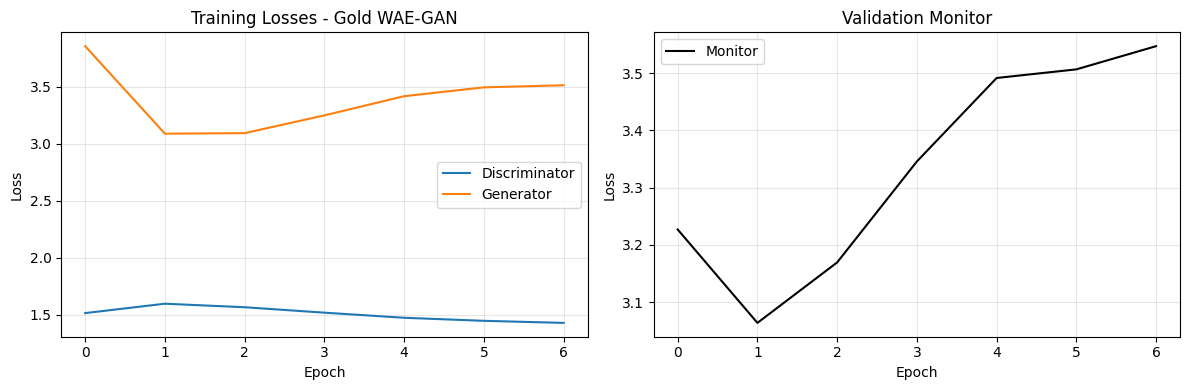

Saved: docs\figures\07_wae_gan_training_curves.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['discriminator'], label='Discriminator')
axes[0].plot(history['generator'], label='Generator')
axes[0].set_title(f'Training Losses - WAE-GAN (Run {BEST_RUN:02d})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['monitor'], color='black', label='Monitor')
axes[1].set_title('Validation Monitor')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_path = FIGURES_DIR / f'05_wae_gan_training_curves_run_{BEST_RUN:02d}.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', save_path.relative_to(PROJECT_ROOT))

## 8. Avaliacao no Conjunto de Teste (Melhor Run)

In [ ]:
print(f"Avaliando melhor run: {BEST_RUN:02d} (checkpoint: {CHECKPOINT_PATH.name})")
best_model = WAEGAN.load(CHECKPOINT_PATH, map_location=str(DEVICE))

train_scores = best_model.predict_anomaly_score(data=X_train_normal)
val_scores = best_model.predict_anomaly_score(data=X_val_normal)
test_scores = best_model.predict_anomaly_score(data=X_test_seq)

threshold = best_model.calculate_threshold(train_scores, multiplier=THRESHOLD_MULTIPLIER)
metrics = compute_anomaly_metrics(y_test_binary, test_scores, threshold=threshold)

print('Threshold:', threshold)
display(pd.Series(metrics).to_frame('value'))

Threshold: 0.15495927445590496


,value
auc_roc,1.000000
average_precision,1.000000
threshold,0.154959
accuracy,0.996228
precision,0.994995
recall,1.000000
f1,0.997491
tn,718.000000
fp,11.000000
fn,0.000000


	value
auc_roc	0.999966
average_precision	0.999989
threshold	0.362007
accuracy	0.995885
precision	0.994993
recall	0.999543
f1	0.997263
tn	718.000000
fp	11.000000
fn	1.000000
tp	2186.000000

## 9. Curva ROC e Distribuicao de Scores

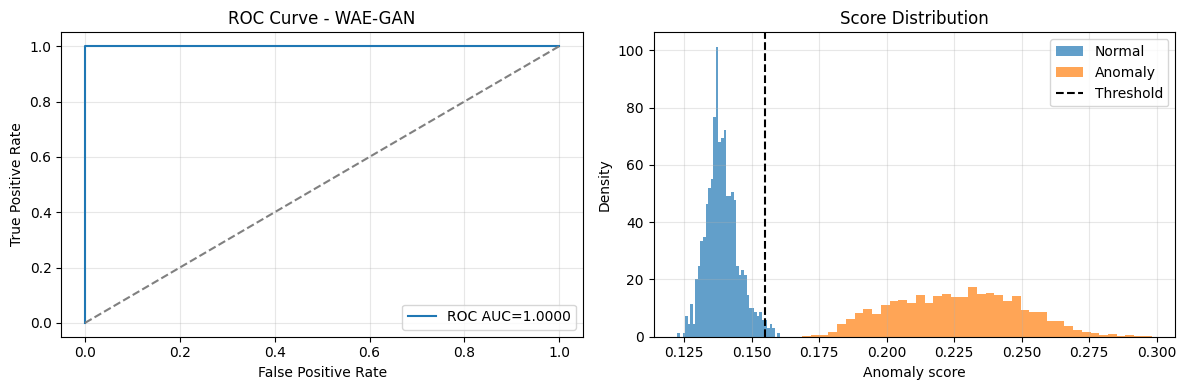

Saved: docs\figures\07_wae_gan_scores.png


In [17]:
fpr, tpr, _ = roc_curve(y_test_binary, test_scores)
normal_scores = test_scores[y_test_binary == 0]
anomaly_scores = test_scores[y_test_binary == 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(fpr, tpr, label=f"ROC AUC={metrics['auc_roc']:.4f}")
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_title('ROC Curve - WAE-GAN')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(normal_scores, bins=40, alpha=0.7, label='Normal', density=True)
axes[1].hist(anomaly_scores, bins=40, alpha=0.7, label='Anomaly', density=True)
axes[1].axvline(threshold, color='black', linestyle='--', label='Threshold')
axes[1].set_title('Score Distribution')
axes[1].set_xlabel('Anomaly score')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_path = FIGURES_DIR / '07_wae_gan_scores.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', save_path.relative_to(PROJECT_ROOT))

## 10. Resumo

Este notebook foi padronizado para comparação com GAT/Transformer usando o mesmo conjunto de seeds fixas (`42..61`) em 20 execuções sem sobrescrever runs anteriores.

**Saídas geradas:**
- `models/wae_gan_runs_20/runset_YYYYMMDD_HHMMSS/wae_gan_run_01.pt` ... `wae_gan_run_20.pt`
- `models/wae_gan_runs_20/runset_YYYYMMDD_HHMMSS/wae_gan_runs_summary.csv`
- `docs/figures/05_wae_gan_training_curves_run_XX.png` (melhor run)
- `docs/figures/07_wae_gan_scores.png`

**Validação no notebook:**
- Execução de 20 runs com seeds fixas e pareadas
- Assertiva de exatamente 20 checkpoints
- Avaliação usando automaticamente o melhor run por `best_monitor`